<a href="https://colab.research.google.com/github/rebelahsan/Mo-Ahsan-Ahmad/blob/main/era5_weekly_data_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/era5-weekly.csv')

# Display the first few rows to understand the structure
print(df.head())

   week  year  avg_max_temp_c_corrected
0     1  1940                 22.915695
1     2  1940                 22.393610
2     3  1940                 22.184807
3     4  1940                 20.956824
4     5  1940                 21.403278


In [2]:
# Filter the data for the years 1996-2023
df_filtered = df[(df['year'] >= 1996) & (df['year'] <= 2023)]

# Check the filtered data
print(df_filtered.head())

      week  year  avg_max_temp_c_corrected
2968     1  1996                 23.225085
2969     2  1996                 21.444264
2970     3  1996                 22.771317
2971     4  1996                 22.604967
2972     5  1996                 22.707477


In [4]:
# Pivot the data to create a matrix for the heatmap
heatmap_data = df_filtered.pivot(index='week', columns='year', values='avg_max_temp_c_corrected')

# Check the pivoted data
print(heatmap_data.head())

year       1996       1997       1998       1999       2000       2001  \
week                                                                     
1     23.225085  21.861394  24.066138  21.264116  21.219366  20.884891   
2     21.444264  23.603677  25.349923  21.434896  20.515427  21.884677   
3     22.771317  20.471959  25.175771  21.674857  19.725450  21.943901   
4     22.604967  21.403581  26.206217  21.148367  22.209222  21.332693   
5     22.707477  21.502593  27.195459  21.323896  21.796471  23.704197   

year       2002       2003       2004       2005  ...       2014       2015  \
week                                              ...                         
1     23.412601  25.066685  21.546659  21.343148  ...  22.273368  22.482444   
2     22.008370  23.842523  21.684711  22.622300  ...  22.480715  21.572356   
3     22.892093  23.218290  24.157597  21.248292  ...  21.462201  21.951726   
4     24.211312  22.668938  24.208954  21.598633  ...  21.825151  22.800464   
5     2

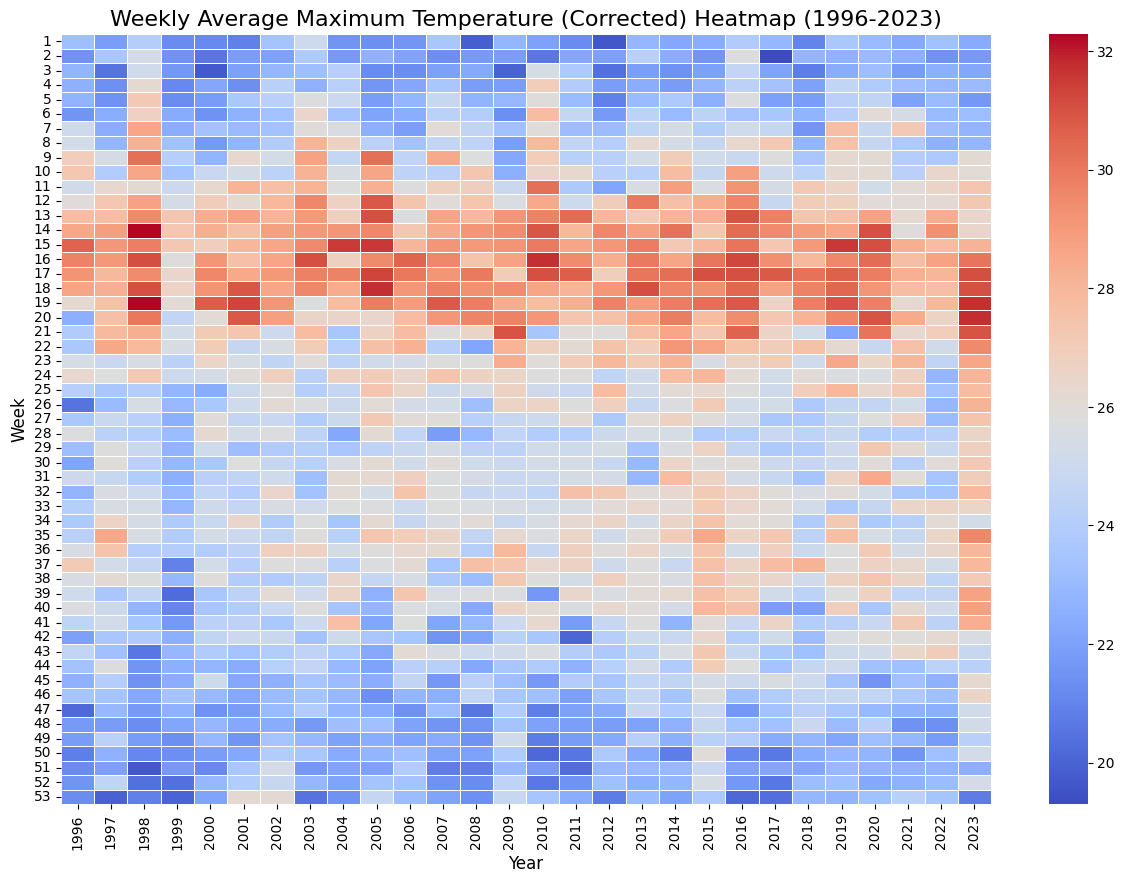

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(15, 10))

# Create the heatmap
sns.heatmap(heatmap_data, cmap='coolwarm', annot=False, linewidths=0.5)

# Add labels and title
plt.title('Weekly Average Maximum Temperature (Corrected) Heatmap (1996-2023)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Week', fontsize=12)

# Show the plot
plt.show()

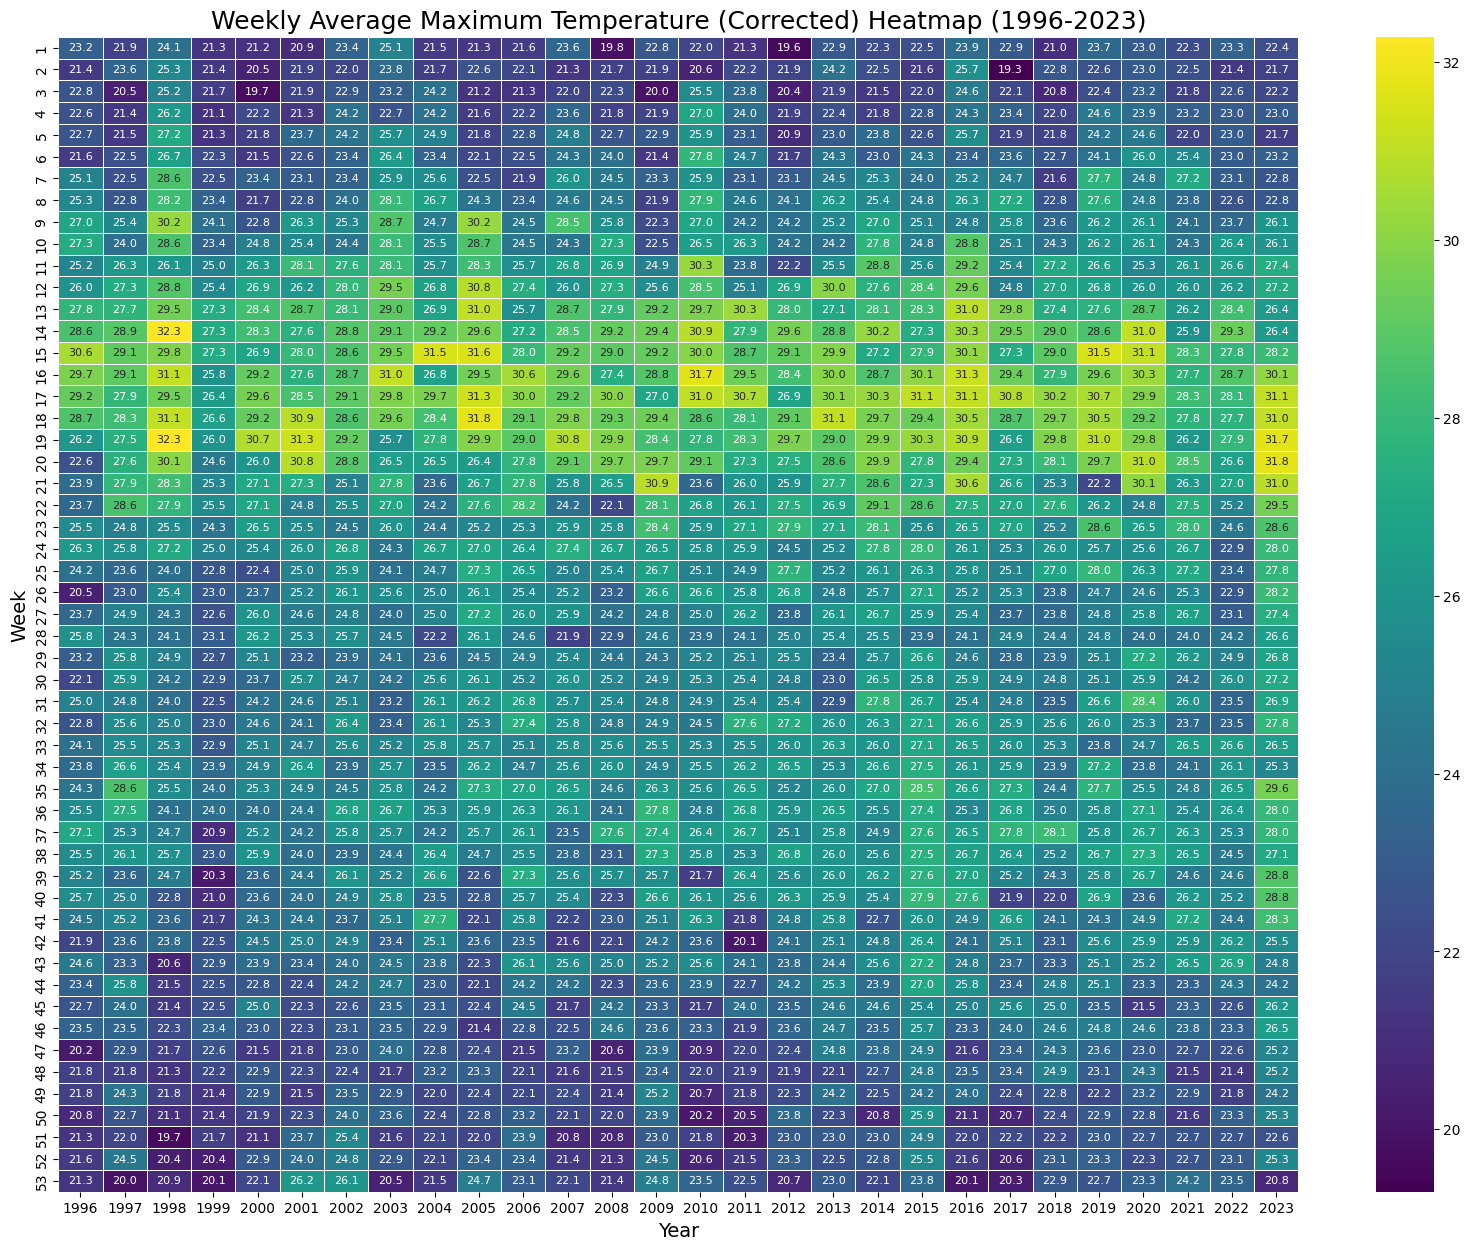

In [6]:
# Customized heatmap with annotations
plt.figure(figsize=(20, 15))
sns.heatmap(heatmap_data, cmap='viridis', annot=True, fmt=".1f", linewidths=0.5, annot_kws={"size": 8})

plt.title('Weekly Average Maximum Temperature (Corrected) Heatmap (1996-2023)', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Week', fontsize=14)

plt.show()

###  Creating the Dynamic Heatmap

In [29]:
import plotly.express as px

# Create the heatmap
fig = px.imshow(
    heatmap_data,
    labels=dict(x="Year", y="Week", color="Average Max Temp (°C)"),
    x=heatmap_data.columns,  # Years
    y=heatmap_data.index,    # Weeks
    color_continuous_scale='Viridis',  # Choose a color scale
    title='Weekly Average Maximum Temperature (Corrected) Heatmap (1996-2023)',
    aspect="auto"  # Automatically adjust aspect ratio
)

# Update layout for better readability and fit
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Week",
    coloraxis_colorbar=dict(title="Temp (°C)"),
    width=900,  # Balanced width
    height=500,  # Reduced height to avoid too much vertical stretching
    margin=dict(l=50, r=50, t=50, b=50)  # Balanced margins
)

# Show the interactive heatmap
fig.show()
